
- Este notebook consiste no desenvolvimento de uma análise de dados completa utilizando dados reais para avaliar a capacidade do discente em utilizar as ferramentas computacionais abordadas durante a aula para importar, organizar, analisar e sumarizar os dados.

## Dados:
- Os conjuntos de dados para este trabalho será:
   - https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
   https://archive.ics.uci.edu/dataset/360/air+quality


## Análise dos dados

Para desenvolver a sua análise, tente seguir o seguinte roteiro

**1. Entendimento dos Dados**
 - Qual é o contexto do dataset?
 - O que cada variável representa?
 - Qual o objetivo potencial da análise?

#### **Resposta Item 1 - Entendimento dos Dados**
 - **Qual é o contexto do dataset?**

 O Dataset se insere no contexto de um sistema de aluguel de bicicletas. Uma aplicação informatizou o processo de cadastramento, aluguel e retorno de bicicletas; e os dados gerados podem ser fonte de insights interessantes sobre a mobilidade urbana.

 - **O que cada variável representa?**

 | Variable Name | Role    | Type        | Description                                                                                                                                 | Units | Missing Values |
|---------------|---------|-------------|---------------------------------------------------------------------------------------------------------------------------------------------|-------|----------------|
| instant       | ID      | Integer     | record index                                                                                                                                |       | no             |
| dteday        | Feature | Date        | date                                                                                                                                        |       | no             |
| season        | Feature | Categorical | 1:winter, 2:spring, 3:summer, 4:fall                                                                                                        |       | no             |
| yr            | Feature | Categorical | year (0: 2011, 1: 2012)                                                                                                                     |       | no             |
| mnth          | Feature | Categorical | month (1 to 12)                                                                                                                             |       | no             |
| hr            | Feature | Categorical | hour (0 to 23)                                                                                                                              |       | no             |
| holiday       | Feature | Binary      | weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)                                                     |       | no             |
| weekday       | Feature | Categorical | day of the week                                                                                                                             |       | no             |
| workingday    | Feature | Binary      | f day is neither weekend nor holiday is 1, otherwise is 0                                                                                   |       | no             |
| weathersit    | Feature | Categorical | - 1: Clear, Few clouds, Partly cloudy, Partly cloudy                                                                                        |       | no             |
| temp          | Feature | Continuous  | Normalized temperature in Celsius. The values are derived via  (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)          | C     | no             |
| atemp         | Feature | Continuous  | Normalized feeling temperature in Celsius. The values are derived via  (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale) | C     | no             |
| hum           | Feature | Continuous  | Normalized humidity. The values are divided to 100 (max)                                                                                    |       | no             |
| windspeed     | Feature | Continuous  | Normalized wind speed. The values are divided to 67 (max)                                                                                   |       | no             |
| casual        | Other   | Integer     | count of casual users                                                                                                                       |       | no             |
| registered    | Other   | Integer     | count of registered users                                                                                                                   |       | no             |
| cnt           | Target  | Integer     | count of total rental bikes including both casual and registered                                                                            |       | no             |

 - **Qual o objetivo potencial da análise?**

Análise exploratória de um dataset gerado a partir de um banco de dados de um sistema de aluguel de bicicletas (Capital Bikeshare em Washington DC, EUA)

Algumas insights sobre mobilidade urbana podem ser extraídos da base.

Perguntas norteadoras:

- **Padrões temporais**: Existe tendência de crescimento no número de corridas ao longo do tempo?
- Como o uso varia ao longo do dia, da semana, de um mês e de um ano?
- **Climáticas**: O Clima impacta o aluguel? Quais variáveis climáticas pesam mais?
- **Comportamentais**: Usuários "casual" e "registered" se comportam diferente? (Hipótese: Registrados são commuters, casuais são turistas/lazer?)
- **Modelagem**: É possível prever a variável "cnt" (count = corridas registered + corridas casual)?

**2. Inspeção Inicial**
 - Qual o tamanho do dataset? (linhas × colunas)
 - Quais os tipos de variáveis? (numérica, categórica, temporal)
 - Existem valores faltantes?
 - Existem dados duplicados?

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
# fetch dataset
bike_sharing = fetch_ucirepo(id=275)

# data (as pandas dataframes)
df = bike_sharing.data.original
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [ ]:
# Qual o tamanho do dataset?
# 17,379 registros com 17 colunas

n_linhas, n_colunas = df.shape
print(f"Dataset: {n_linhas:,} linhas × {n_colunas} colunas")
print(f"Shape: {df.shape}\n")
print(f"Dtype:\n {df.dtypes}\n")
print(f"Cardinalidade:\n {df.nunique()}\n")
print(f"Valores nulos:\n { df.isnull().sum()}")

Dataset: 17,379 linhas × 17 colunas
Shape: (17379, 17)

Dtype:
 instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Cardinalidade:
 instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64

Valores nulos:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
t

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Quais os tipos de variáveis? Existem valores faltantes?

|   Coluna   | Tipo conceitual |       Subtipo       |                         Observação                        | Units | Missing Values |
|:----------:|:---------------:|:-------------------:|:---------------------------------------------------------:|-------|----------------|
| instant    | ID              | —                   | Apenas índice de registro, não é uma feature              |       | no             |
| dteday     | Temporal        | Data                | Atualmente como object, deve ser convertida para datetime |       | no             |
| season     | Categórica      | Nominal (4 cat.)    | 1=winter, 2=spring, 3=summer, 4=fall                      |       | no             |
| yr         | Categórica      | Binária             | 0=2011, 1=2012                                            |       | no             |
| mnth       | Categórica      | Ordinal cíclica     | 1 a 12                                                    |       | no             |
| hr         | Categórica      | Ordinal cíclica     | 0 a 23                                                    |       | no             |
| holiday    | Categórica      | Binária             | 0=não, 1=sim                                              |       | no             |
| weekday    | Categórica      | Ordinal cíclica     | 0 a 6                                                     |       | no             |
| workingday | Categórica      | Binária             | 0=não feriado e não fim de semana, 1=caso contrário       |       | no             |
| weathersit | Categórica      | Ordinal             | 1=melhor tempo, 4=pior tempo                              |       | no             |
| temp       | Numérica        | Contínua            | Normalizada em [0, 1]                                     | C     | no             |
| atemp      | Numérica        | Contínua            | Normalizada em [0, 1]                                     | C     | no             |
| hum        | Numérica        | Contínua            | Normalizada em [0, 1]                                     |       | no             |
| windspeed  | Numérica        | Contínua            | Normalizada em [0, 1]                                     |       | no             |
| casual     | Numérica        | Discreta (contagem) | Variável-alvo (usuários casuais)                          |       | no             |
| registered | Numérica        | Discreta (contagem) | Variável-alvo (usuários cadastrados)                      |       | no             |
| cnt        | Numérica        | Discreta (contagem) | Variável-alvo principal (cnt = casual + registered)       |       | no             |

Das 17 Colunas: 1 ID, 1 Temporal, 8 Categóricas, 7 Numéricas

In [ ]:
df.describe() # faltando as colunas com do tipo object (dteday)

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
print(f"Linhas com hum = 0: {(df['hum'] == 0).sum()}")
print(f"Linhas com windspeed = 0: {(df['windspeed'] == 0).sum()}")

Linhas com hum = 0: 22
Linhas com windspeed = 0: 2180


In [ ]:
# Quando ocorrem as 22 linhas com hum = 0?
df.loc[df['hum'] == 0, ['dteday', 'hr', 'temp', 'weathersit']]

,dteday,hr,temp,weathersit
1551,2011-03-10,0,0.34,3
1552,2011-03-10,1,0.34,3
1553,2011-03-10,2,0.34,3
1554,2011-03-10,5,0.36,3
1555,2011-03-10,6,0.36,3
1556,2011-03-10,7,0.38,3
1557,2011-03-10,8,0.38,3
1558,2011-03-10,9,0.40,3
1559,2011-03-10,10,0.40,3
1560,2011-03-10,11,0.40,3


In [ ]:
df.loc[df['dteday'] == '2011-03-10']

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12
1556,1557,2011-03-10,1,0,3,7,0,4,1,3,0.38,0.3939,0.0,0.2239,1,36,37
1557,1558,2011-03-10,1,0,3,8,0,4,1,3,0.38,0.3939,0.0,0.2836,1,43,44
1558,1559,2011-03-10,1,0,3,9,0,4,1,3,0.40,0.4091,0.0,0.2239,1,23,24
1559,1560,2011-03-10,1,0,3,10,0,4,1,3,0.40,0.4091,0.0,0.1642,0,17,17
1560,1561,2011-03-10,1,0,3,11,0,4,1,3,0.40,0.4091,0.0,0.2537,6,5,11


## Anomalias no dia 10/03/2011

Registros com úmidade 0 ocorreram no dia 10/03/2011, quando foi registrado clima ruim (weathersit 2 e 3 ao longo do dia), com Chuvas e/ou neve leves + trovoada + nuvens dispersas)

O que pode ter sido uma das causas de falha de sensor.

Outras anomalias foram detectadas no dia 10/03/2011, as horas 3 e 4 do dia não possuem qualquer registro.

In [ ]:
categoricas = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
df[categoricas].nunique().sort_values()

,0
yr,2
holiday,2
workingday,2
season,4
weathersit,4
weekday,7
mnth,12
hr,24


In [ ]:
# quando ocorreram as 2180 linhas com windspeed = 0?
df.loc[df['windspeed'] == 0, ['dteday', 'hr', 'temp', 'weathersit', 'windspeed']]

,dteday,hr,temp,weathersit,windspeed
0,2011-01-01,0,0.24,1,0.0
1,2011-01-01,1,0.22,1,0.0
2,2011-01-01,2,0.22,1,0.0
3,2011-01-01,3,0.24,1,0.0
4,2011-01-01,4,0.24,1,0.0
...,...,...,...,...,...
17319,2012-12-29,12,0.20,3,0.0
17320,2012-12-29,13,0.20,3,0.0
17322,2012-12-29,15,0.24,2,0.0
17330,2012-12-29,23,0.26,2,0.0


In [ ]:
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")
print(f"Duplicatas em (dteday, hr): {df.duplicated(subset=['dteday', 'hr']).sum()}")

Linhas totalmente duplicadas: 0
Duplicatas em (dteday, hr): 0


In [ ]:
# ---- Checagem de continuidade temporal ----
# O dataset tem registros horários. Verificamos se a série está completa,
# comparando todas as horas esperadas (de min até max) com as presentes.

# Constrói um timestamp único por linha combinando dteday + hr
df_temporal = df.copy()
df_temporal['dteday'] = pd.to_datetime(df_temporal['dteday'])
df_temporal['timestamp'] = (
    df_temporal['dteday'] + pd.to_timedelta(df_temporal['hr'], unit='h')
)

# Gera o índice horário esperado, do primeiro ao último timestamp
inicio = df_temporal['timestamp'].min()
fim    = df_temporal['timestamp'].max()
esperado = pd.date_range(start=inicio, end=fim, freq='h')

# Quais horas estão faltando?
faltando = esperado.difference(df_temporal['timestamp'])

print(f"Período coberto: {inicio} → {fim}")
print(f"Horas esperadas: {len(esperado):,}")
print(f"Horas presentes: {len(df_temporal):,}")
print(f"Horas ausentes:  {len(faltando):,}")
print(f"Cobertura:       {len(df_temporal) / len(esperado):.2%}")

Período coberto: 2011-01-01 00:00:00 → 2012-12-31 23:00:00
Horas esperadas: 17,544
Horas presentes: 17,379
Horas ausentes:  165
Cobertura:       99.06%


In [ ]:
# Em quais dias estão as horas faltando?
lacunas_por_dia = (
    pd.Series(faltando)
    .dt.date
    .value_counts()
    .sort_values(ascending=False)
)

print(f"Total de dias com pelo menos 1 hora ausente: {len(lacunas_por_dia)}")
print(f"\nTop 10 dias com mais horas faltando:")
print(lacunas_por_dia.head(10))

print(f"\nDistribuição: quantos dias têm N horas faltando?")
print(lacunas_por_dia.value_counts().sort_index())

Total de dias com pelo menos 1 hora ausente: 76

Top 10 dias com mais horas faltando:
2012-10-29    23
2011-01-27    16
2012-10-30    13
2011-01-18    12
2011-01-26     8
2011-08-28     7
2011-08-27     6
2011-02-22     6
2011-02-11     2
2011-01-03     2
Name: count, dtype: int64

Distribuição: quantos dias têm N horas faltando?
count
1     62
2      6
6      2
7      1
8      1
12     1
13     1
16     1
23     1
Name: count, dtype: int64


In [ ]:
df.loc[df['dteday'] == '2012-10-29']

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
15883,15884,2012-10-29,4,1,10,0,0,1,1,3,0.44,0.4394,0.88,0.3582,2,20,22


In [ ]:
# Datas com gaps grandes — verificando contexto meteorológico
datas_suspeitas = ['2011-01-18', '2011-01-26', '2011-01-27',
                   '2011-08-27', '2011-08-28',
                   '2012-10-29', '2012-10-30']

for data in datas_suspeitas:
    sub = df.loc[df['dteday'] == data, ['hr', 'temp', 'hum', 'windspeed', 'weathersit']]
    print(f"\n=== {data} (registros: {len(sub)}/24) ===")
    print(sub.to_string(index=False))


=== 2011-01-18 (registros: 12/24) ===
 hr  temp  hum  windspeed  weathersit
 12  0.20 0.86     0.3284           2
 13  0.20 0.86     0.2239           2
 14  0.22 0.80     0.1642           2
 15  0.22 0.87     0.1642           2
 16  0.22 0.87     0.1940           2
 17  0.22 0.82     0.1940           2
 18  0.22 0.80     0.1642           2
 19  0.22 0.80     0.1343           2
 20  0.22 0.87     0.0000           2
 21  0.22 0.93     0.1045           2
 22  0.22 0.93     0.0896           2
 23  0.22 0.93     0.0000           2

=== 2011-01-26 (registros: 16/24) ===
 hr  temp  hum  windspeed  weathersit
  0  0.22 0.69     0.1343           2
  1  0.24 0.65     0.1343           2
  2  0.22 0.69     0.1940           3
  5  0.20 0.86     0.2836           3
  6  0.20 0.86     0.2836           3
  7  0.22 0.87     0.2985           3
  8  0.22 0.87     0.2985           3
  9  0.22 0.87     0.2985           3
 10  0.22 0.93     0.2836           3
 11  0.22 0.93     0.3284           3
 12  0.22 

### Respostas Item 2 - Inspeção Inicial

- **Qual o tamanho do dataset?**
    - Tamanho do dataset: 17,379 registros em 17 Colunas
        

- **Quais os tipos de variáveis?**
    - 1 Coluna ID
    - 1 Coluna Temporal
    - 8 Categóricas
    - 7 Numéricas

- **Existem valores faltantes?**
    - Nenhum missing value formal
    - Porém
        - 22 registros de Umidade 0% (no dia 10/03/2011), podendo indicar alguma falha na captação dos dados.

        - 2180 registros com velocidade do vento em 0 (Zero), o que também pode indicar alguma falha na coleta de dados.

        - 76 dias com ao menos 1h de registro faltando.

        - 165h estão faltando
            - Período:
                - 01-01-2011 -> 31/12/2012 (731 dias)
                - 731 dias x 24h = 17544h
                - 17544 - 17379 = 165h faltantes
            - 76 dias com ao menos 1h faltando
            - dias
                - 18, 26 e 27 Janeiro 2011: Tempestade forte
                - 27-28 de Agosto 2011: Furacão Irene na costa leste
                - 29-30/10/2012: Furacão Sandy atinge costa leste dos EUA, causando suspensão dos transportes públicos. (1 registro, dia 29 na hora 0)
                


    - Após pesquisar um pouco
        - alguns sensores tem um limiar mínimo de captação (stall speed), que velocidades abaixo desse limiar não são registrados, fazendo com que registros de velocidades abaixo desse limiar sejam zero.

        - O [teorema da bola cabeluda](https://makeagif.com/i/gGbV_j) (hairy ball theorem) implica que sempre existem pontos sem vento horizontal na superfície da Terra.

**3. Limpeza de Dados**
 - Como devo tratar os valores ausentes?
 - Como devo tratar as duplicatas?
 - Existem dados inconsistentes? (ex: categorias escritas de forma diferente)


In [ ]:
import pandas as pd

In [ ]:
# Cria a versão limpa do dataframe (df original permanece intacto)
df_clean = df.copy()

# Converte dteday de string para datetime
df_clean['dteday'] = pd.to_datetime(df_clean['dteday'])

# Verifica
print(f"Tipo de dteday: {df_clean['dteday'].dtype}")
print(f"Exemplo: {df_clean['dteday'].iloc[0]}")
print(f"Intervalo: {df_clean['dteday'].min()} até {df_clean['dteday'].max()}")

Tipo de dteday: datetime64[ns]
Exemplo: 2011-01-01 00:00:00
Intervalo: 2011-01-01 00:00:00 até 2012-12-31 00:00:00


In [ ]:
df_clean.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [ ]:
# Valores esperados segundo a documentação UCI
esperado = {
    'season':     [1, 2, 3, 4],
    'yr':         [0, 1],
    'mnth':       list(range(1, 13)),
    'hr':         list(range(0, 24)),
    'holiday':    [0, 1],
    'weekday':    list(range(0, 7)),
    'workingday': [0, 1],
    'weathersit': [1, 2, 3, 4],
}

print(f"{'Coluna':<12} {'Esperado':<28} {'Observado':<28} {'OK?'}")
print('-' * 80)
for col, valores_esp in esperado.items():
    valores_obs = sorted(df_clean[col].unique())
    ok = '✅' if valores_obs == valores_esp else '❌'
    print(f"{col:<12} {str(valores_esp):<28} {str(valores_obs):<28} {ok}")

Coluna       Esperado                     Observado                    OK?
--------------------------------------------------------------------------------
season       [1, 2, 3, 4]                 [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ✅
yr           [0, 1]                       [np.int64(0), np.int64(1)]   ✅
mnth         [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] ✅
hr           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)] ✅
holiday      [0, 1]           

In [ ]:
# Desnormalização — cria novas colunas, mantém as originais
df_clean['temp_celsius']     = df_clean['temp'] * 47 - 8      # range 47, offset -8
df_clean['atemp_celsius']    = df_clean['atemp'] * 66 - 16    # range 66, offset -16
df_clean['hum_pct']          = df_clean['hum'] * 100          #
df_clean['windspeed_real']   = df_clean['windspeed'] * 67     # provavelmente km/h

# Verificação
df_clean[['temp', 'temp_celsius',
          'atemp', 'atemp_celsius',
          'hum', 'hum_pct',
          'windspeed', 'windspeed_real']].describe()

,temp,temp_celsius,atemp,atemp_celsius,hum,hum_pct,windspeed,windspeed_real
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,15.358397,0.475775,15.401157,0.627229,62.722884,0.190098,12.736540
std,0.192556,9.050138,0.171850,11.342114,0.192930,19.292983,0.122340,8.196795
min,0.020000,-7.060000,0.000000,-16.000000,0.000000,0.000000,0.000000,0.000000
25%,0.340000,7.980000,0.333300,5.997800,0.480000,48.000000,0.104500,7.001500
50%,0.500000,15.500000,0.484800,15.996800,0.630000,63.000000,0.194000,12.998000
75%,0.660000,23.020000,0.621200,24.999200,0.780000,78.000000,0.253700,16.997900
max,1.000000,39.000000,1.000000,50.000000,1.000000,100.000000,0.850700,56.996900


In [ ]:
numericas_orig    = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
numericas_reais   = ['temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_real', 'casual', 'registered', 'cnt']

### Resumo das decisões de limpeza

- **Cópia preservada:** `df_clean = df.copy()`, `df` original intacto.
- **Conversão de tipo:** `dteday` convertida de `object` para `datetime64[ns]`.
- **`hum = 0` (22 registros em 10/03/2011):** mantido. Provável falha
  de sensor em dia de clima ruim, documentada.
- **165h ausentes (76 dias):** mantidas. As maiores lacunas têm causa
  meteorológica real (Sandy, Irene, tempestades de inverno de 2011);
  imputar seria inventar demanda.
- **`windspeed = 0` (2180 registros):** mantido. Atribuído ao *stall
  speed* do anemômetro.
- **Duplicatas:** nenhuma encontrada.
- **Consistência categórica:** as 8 variáveis categóricas (`season`,
  `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`)
  contêm exatamente os valores documentados pela UCI.
- **Desnormalização:** criadas colunas auxiliares em unidades reais
  (`temp_celsius`, `atemp_celsius`, `hum_pct`, `windspeed_real`),
  preservando as originais normalizadas para eventual uso em modelagem.
- **Tipagem das categóricas:** mantidas como `int` para flexibilidade
  (algumas têm ordem natural — `hr`, `mnth`, `season`). A consistência
  é garantida pela seleção explícita de colunas via listas
  `numericas_*` e `categoricas`.

**4. Análise Univariada**
 - Calcule para cada variável:
    - Medidas de tendência central: média, mediana
    - Medidas de dispersão: variância, desvio padrão, amplitude
  - Verifique a distribuição através de gráficos como:
    - histogramas
    - boxplots
    - gráficos de barras



In [ ]:
print('--- Medidas de Tendência Central e Dispersão para Variáveis Numéricas Contínuas ---')

#desnormalização
# df_clean['temp'] = df_clean['temp'] * 41
# df_clean['atemp'] = df_clean['atemp'] * 50
# df_clean['hum'] = df_clean['hum'] * 100
# df_clean['windspeed'] = df_clean['windspeed'] * 67

# Definindo as colunas numéricas que são de fato contínuas para estas análises
# Excluímos 'instant' por ser um ID e 'yr', 'mnth', 'hr', 'season', etc., por serem categóricas/ordinais mesmo sendo numéricas.
# numerical_continuous_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

numerical_continuous_cols = ['temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_real', 'casual', 'registered', 'cnt']
for col in numerical_continuous_cols:
    print(f"\n--- Variável: {col.upper()} ---")

    # Medidas de Tendência Central
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    print(f"   Média: {mean_val:.4f}")
    print(f"   Mediana: {median_val:.4f}")

    # Medidas de Dispersão
    variance_val = df_clean[col].var()
    std_dev_val = df_clean[col].std()
    range_val = df_clean[col].max() - df_clean[col].min()
    print(f"   Variância: {variance_val:.4f}")
    print(f"   Desvio Padrão: {std_dev_val:.4f}")
    print(f"   Amplitude (Max - Min): {range_val:.4f}")

# Exibir um resumo estatístico completo para as colunas selecionadas
print("\n--- Resumo Estatístico Completo (describe) ---")
display(df_clean[numerical_continuous_cols].describe())

--- Medidas de Tendência Central e Dispersão para Variáveis Numéricas Contínuas ---

--- Variável: TEMP_CELSIUS ---
   Média: 15.3584
   Mediana: 15.5000
   Variância: 81.9050
   Desvio Padrão: 9.0501
   Amplitude (Max - Min): 46.0600

--- Variável: ATEMP_CELSIUS ---
   Média: 15.4012
   Mediana: 15.9968
   Variância: 128.6436
   Desvio Padrão: 11.3421
   Amplitude (Max - Min): 66.0000

--- Variável: HUM_PCT ---
   Média: 62.7229
   Mediana: 63.0000
   Variância: 372.2192
   Desvio Padrão: 19.2930
   Amplitude (Max - Min): 100.0000

--- Variável: WINDSPEED_REAL ---
   Média: 12.7365
   Mediana: 12.9980
   Variância: 67.1875
   Desvio Padrão: 8.1968
   Amplitude (Max - Min): 56.9969

--- Variável: CASUAL ---
   Média: 35.6762
   Mediana: 17.0000
   Variância: 2430.9860
   Desvio Padrão: 49.3050
   Amplitude (Max - Min): 367.0000

--- Variável: REGISTERED ---
   Média: 153.7869
   Mediana: 115.0000
   Variância: 22909.0280
   Desvio Padrão: 151.3573
   Amplitude (Max - Min): 886.0000

--

,temp_celsius,atemp_celsius,hum_pct,windspeed_real,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,15.358397,15.401157,62.722884,12.736540,35.676218,153.786869,189.463088
std,9.050138,11.342114,19.292983,8.196795,49.305030,151.357286,181.387599
min,-7.060000,-16.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,7.980000,5.997800,48.000000,7.001500,4.000000,34.000000,40.000000
50%,15.500000,15.996800,63.000000,12.998000,17.000000,115.000000,142.000000
75%,23.020000,24.999200,78.000000,16.997900,48.000000,220.000000,281.000000
max,39.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


### Leitura das estatísticas descritivas

**Variáveis climáticas (`temp_celsius`, `atemp_celsius`, `hum_pct`,
`windspeed_real`):** todas têm média ≈ mediana, indicando distribuição
aproximadamente simétrica. Esse padrão é esperado para variáveis com
ciclo anual — a variação interna do dataset reflete a sazonalidade
(verão quente, inverno frio) mais do que ruído aleatório.

**Variáveis de demanda (`casual`, `registered`, `cnt`):** apresentam
**média substancialmente maior que mediana**, característica de
distribuição com **assimetria à direita** (cauda longa para valores
altos). Em particular, `casual` tem desvio padrão maior que a média
(49.3 vs 35.7) — sinal de cauda pesada. Isso indica que a maioria
das horas tem poucos aluguéis, com horários de pico puxando a média
para cima.

**Comparação `casual` vs `registered`:** registrados têm volume médio
~4× maior que casuais (153.8 vs 35.7), mas variabilidade relativa
similar. A diferença sugere perfis de uso distintos — hipótese a
investigar na análise bivariada.

### Distribuição das Variáveis Numéricas Contínuas (Histogramas e Boxplots)

Vamos visualizar a distribuição das variáveis numéricas contínuas para identificar a forma da distribuição, a presença de outliers e a dispersão dos dados.

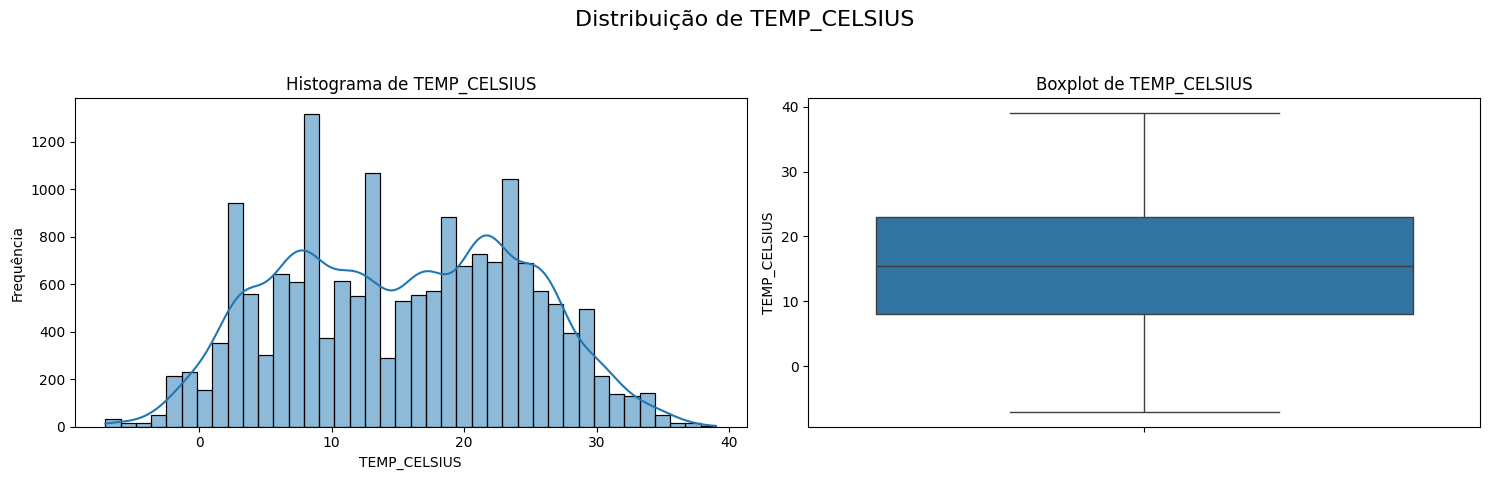

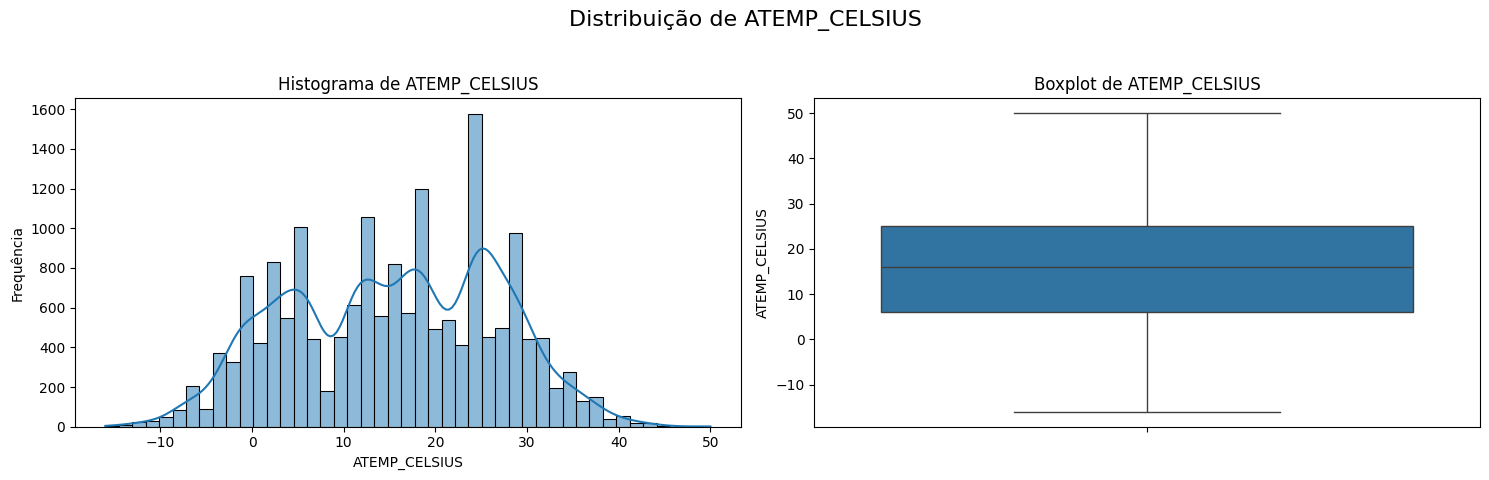

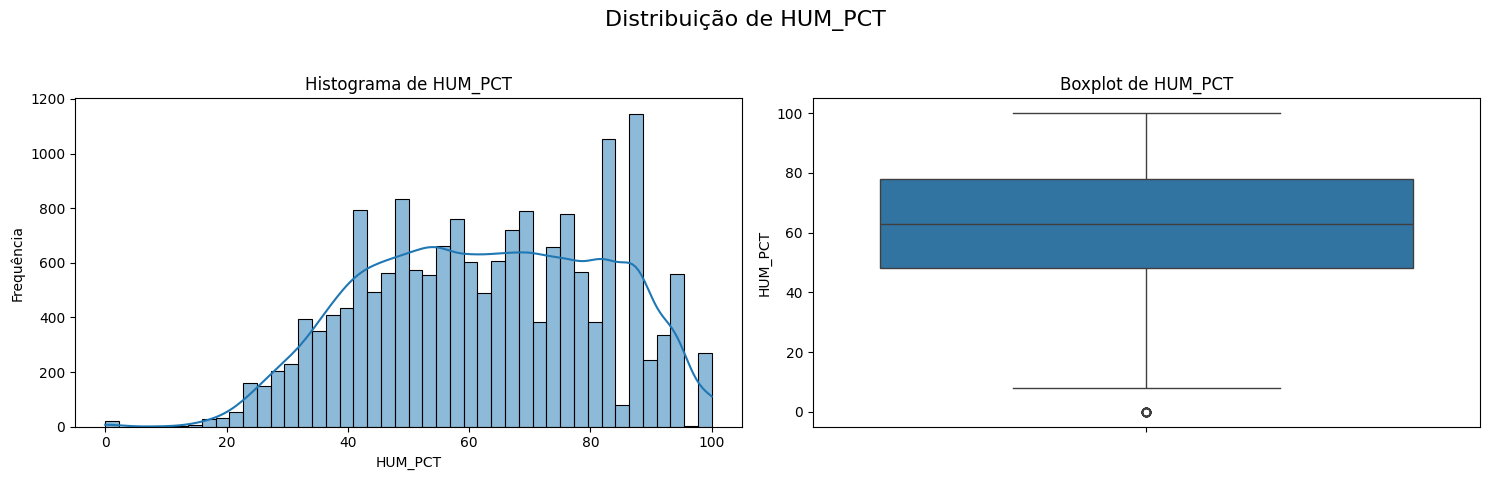

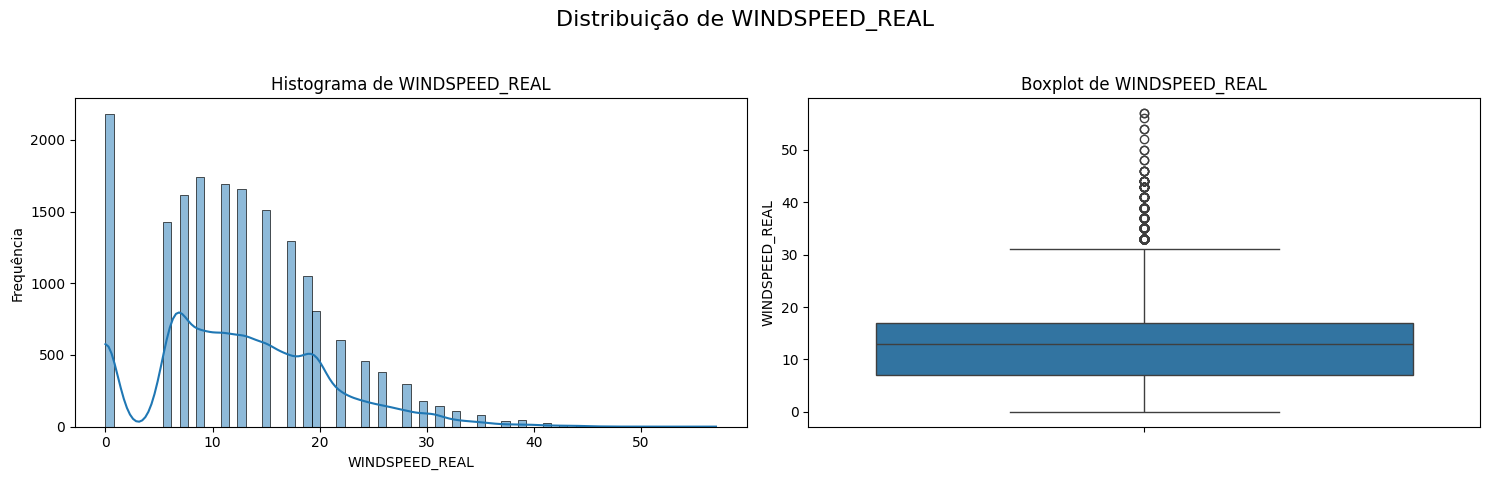

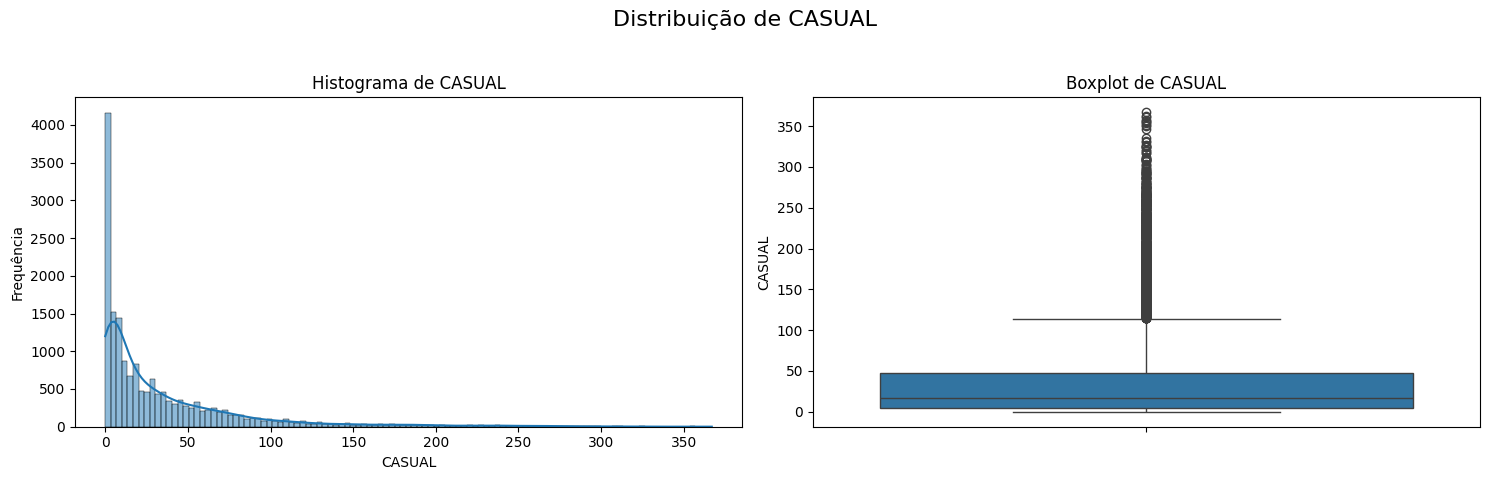

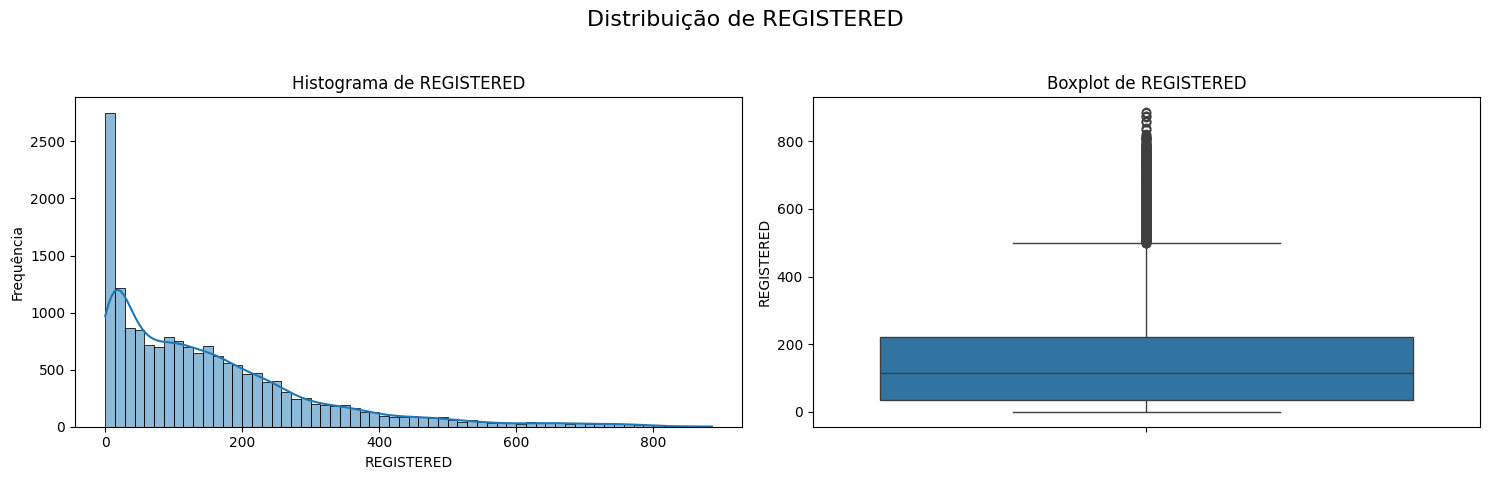

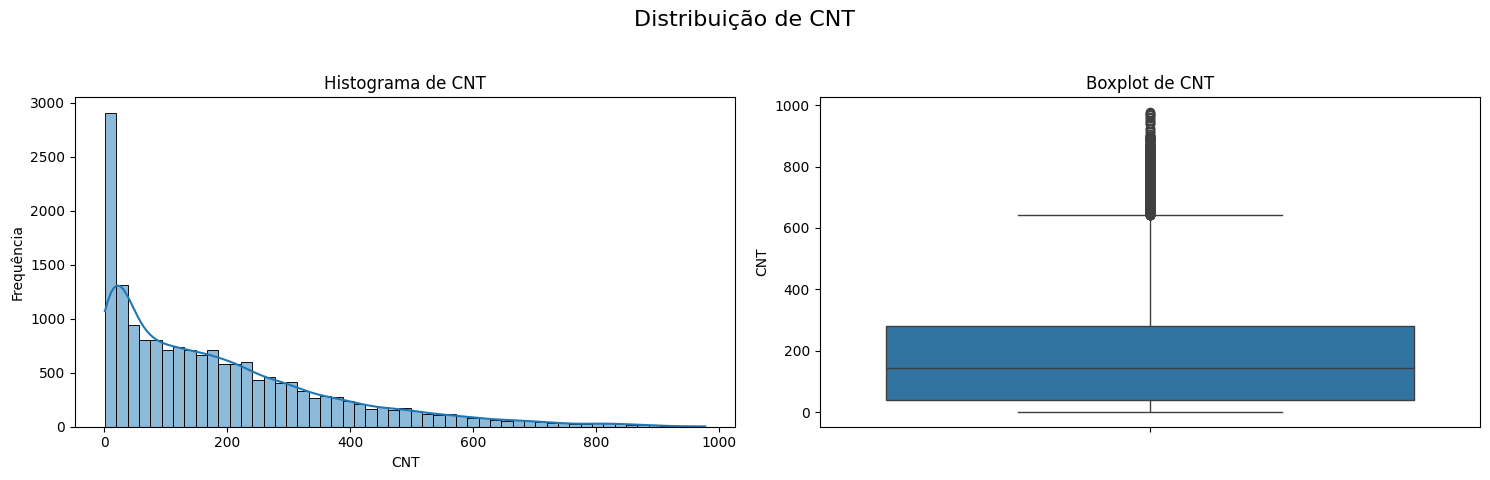

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis numéricas contínuas para histogramas e boxplots
# numerical_continuous_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
numerical_continuous_cols = ['temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_real',
                             'casual', 'registered', 'cnt']
for col in numerical_continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Distribuição de {col.upper()}', fontsize=16)

    # Histograma
    sns.histplot(df_clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col.upper()}')
    axes[0].set_xlabel(col.upper())
    axes[0].set_ylabel('Frequência')

    # Boxplot
    sns.boxplot(y=df_clean[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col.upper()}')
    axes[1].set_ylabel(col.upper())

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição do título
    plt.show()

### Leitura dos histogramas e boxplots

**Temperaturas (`temp_celsius`, `atemp_celsius`):** distribuições
**multimodais**, com 3-4 picos visíveis. Provavelmente refletem as
modas climáticas das estações do ano (inverno ~5-8°C, primavera/outono
~15°C, verão ~22-26°C). A estatística descritiva (média ≈ mediana ≈
15°C) esconde essa estrutura — só o histograma a revela. Boxplot sem
outliers, amplitude natural.

**Umidade (`hum_pct`):** distribuição **assimétrica à esquerda**, com
moda em ~85% e cauda fina em direção a valores baixos. Sugere clima
predominantemente úmido (consistente com DC, próxima ao mar), com
episódios mais secos como exceção. O boxplot revela **um ponto
isolado em 0%** — visualização dos 22 registros de falha de sensor
documentados na Etapa 2.

**Vento (`windspeed_real`):** distribuição com **pico anormal em 0**
(>2000 registros) — visualização clara do *stall speed* do
anemômetro. Excluindo esse pico, a distribuição segue padrão típico
com cauda à direita. Boxplot mostra outliers acima de ~32 km/h
correspondentes a eventos meteorológicos extremos identificados na
Etapa 2.

**Variáveis de demanda (`casual`, `registered`, `cnt`):** todas
exibem **forte assimetria à direita** — pico massivo próximo de 0
e cauda longa para valores altos. Maioria das horas tem poucos
aluguéis; horas de pico (manhã/tarde em dias úteis, fins de semana
ensolarados) puxam a cauda. Os boxplots flagram muitos pontos como
outliers, mas estes representam **horas de pico legítimas**, não
erros — a regra estatística do 1.5×IQR é inadequada para variáveis
de contagem com cauda pesada.

`casual` é o caso mais extremo (std=49.3 > média=35.7), indicando
cauda muito pesada. `registered` tem comportamento mais regular
(std/média ≈ 0.98), sugerindo uso recorrente — provavelmente
*commuters*. Esta diferença reforça a hipótese de **perfis de
usuário distintos** levantada na Etapa 1.

### Distribuição das Variáveis Categóricas/Ordinais (Gráficos de Barras)

Para as variáveis categóricas e ordinais (que podem ser representadas por números inteiros), utilizaremos gráficos de barras para visualizar a contagem de ocorrências de cada categoria.

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


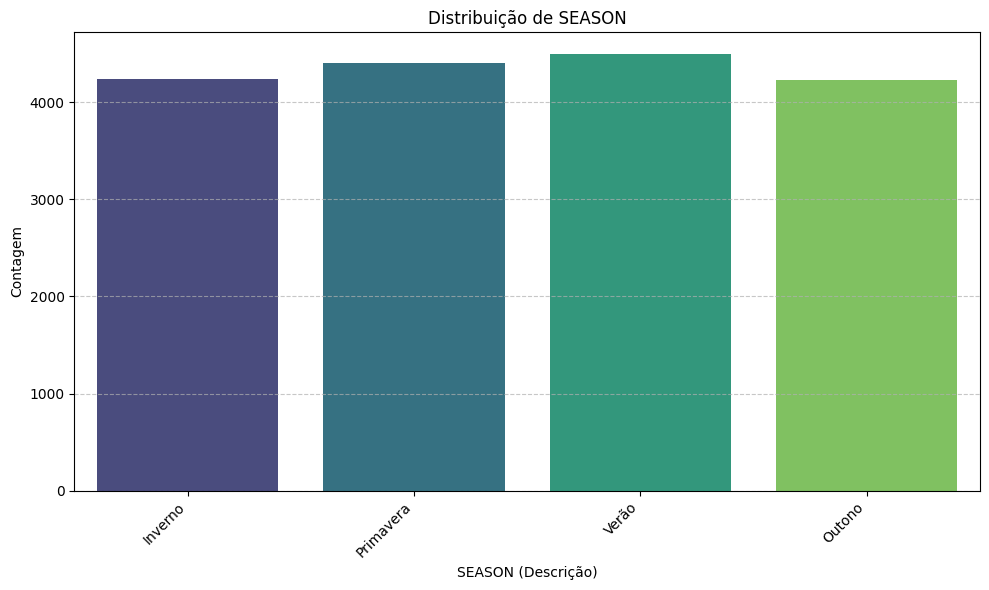

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


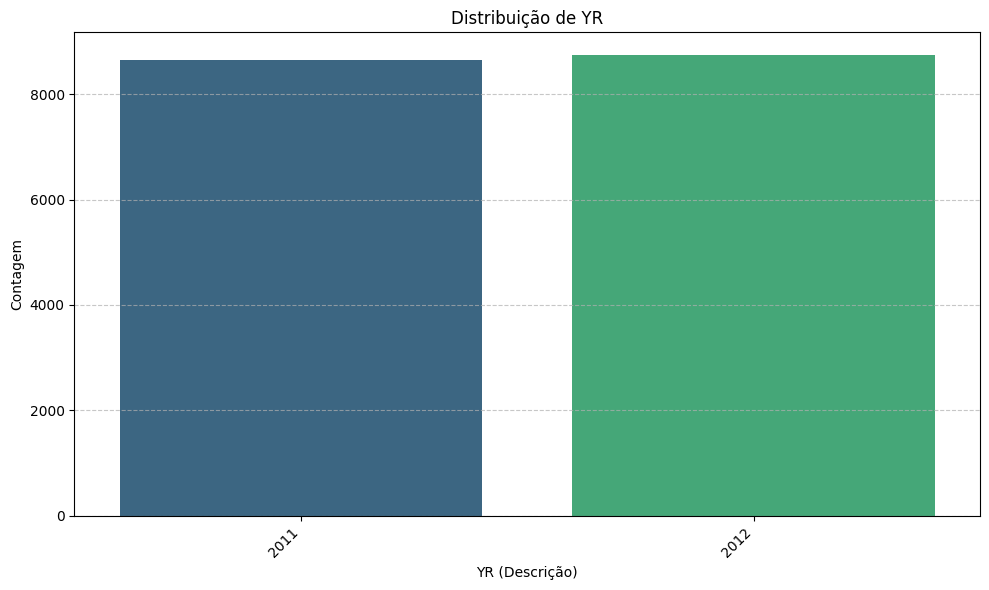

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


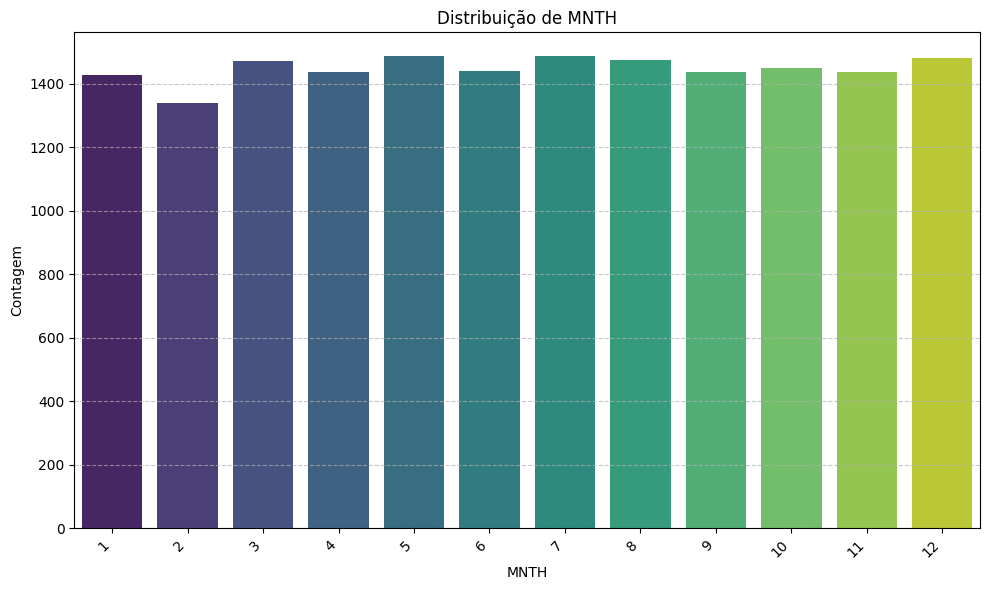

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


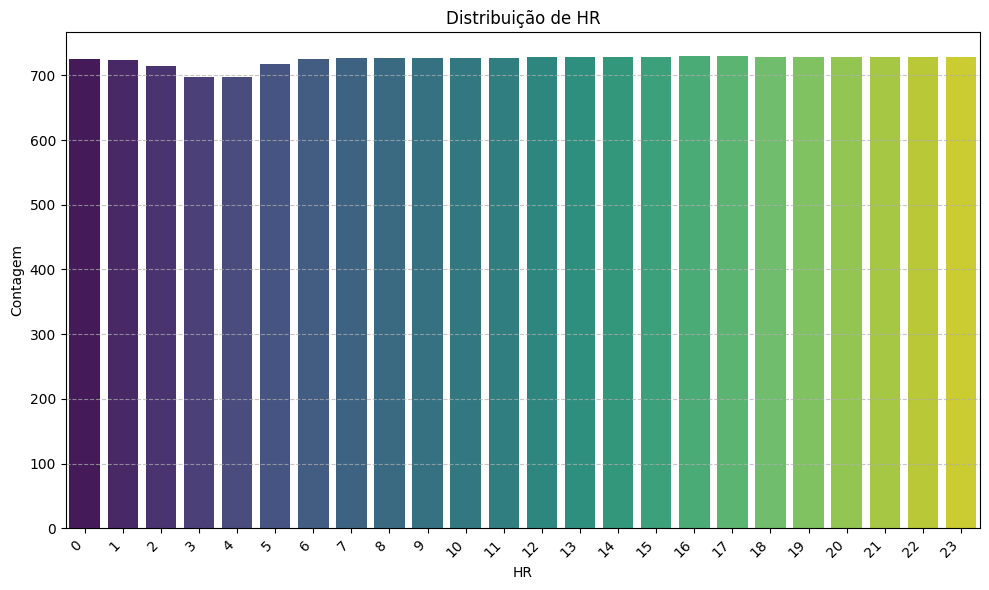

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


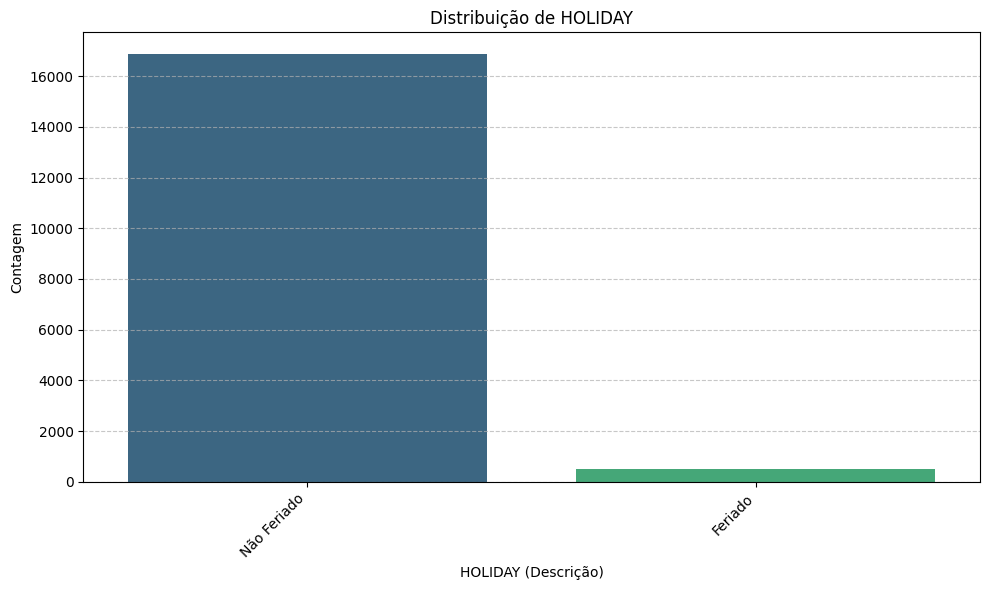

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


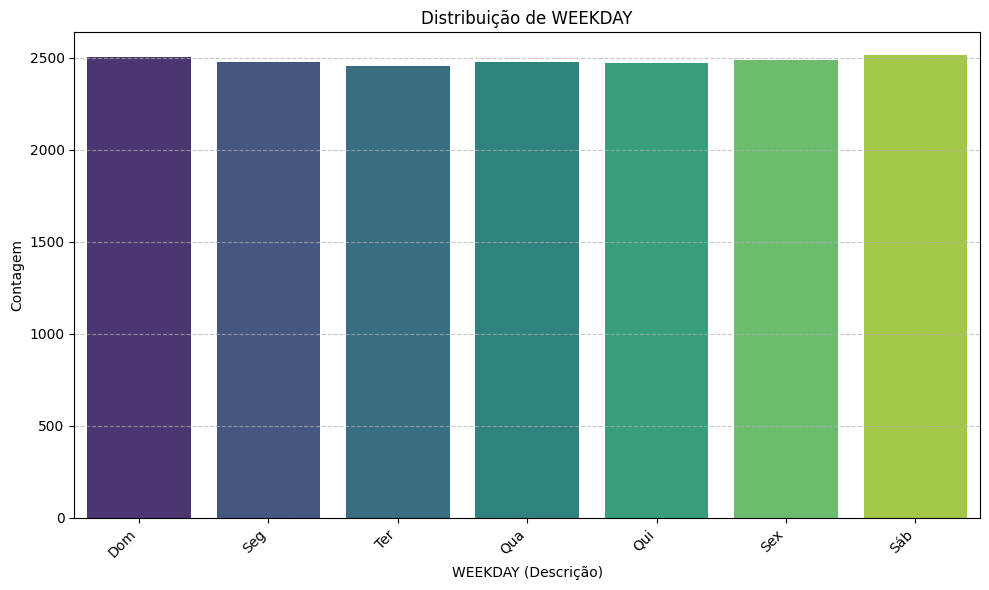

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


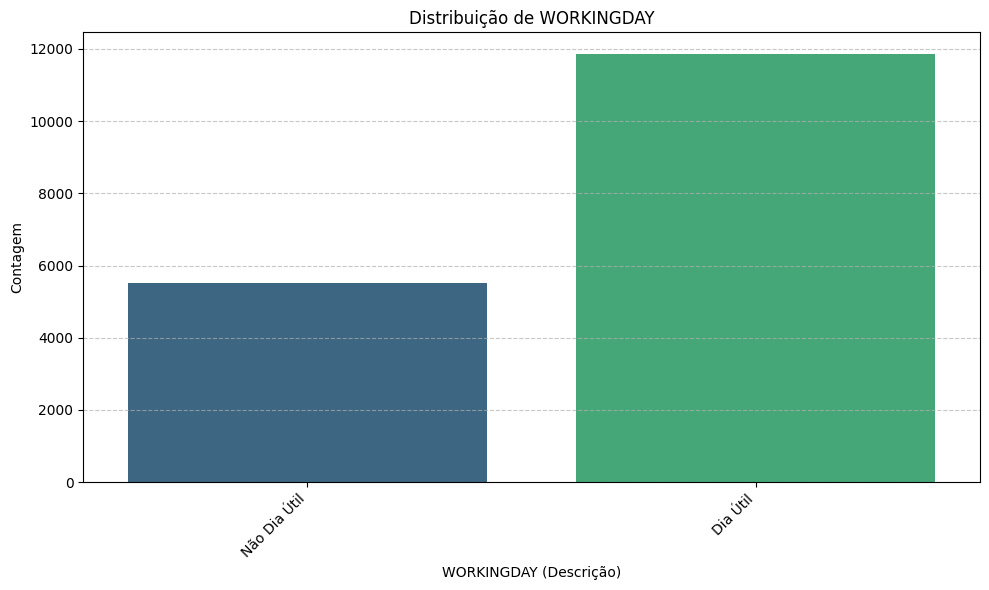

/tmp/ipykernel_10207/89532090.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=value_counts.values, palette='viridis')


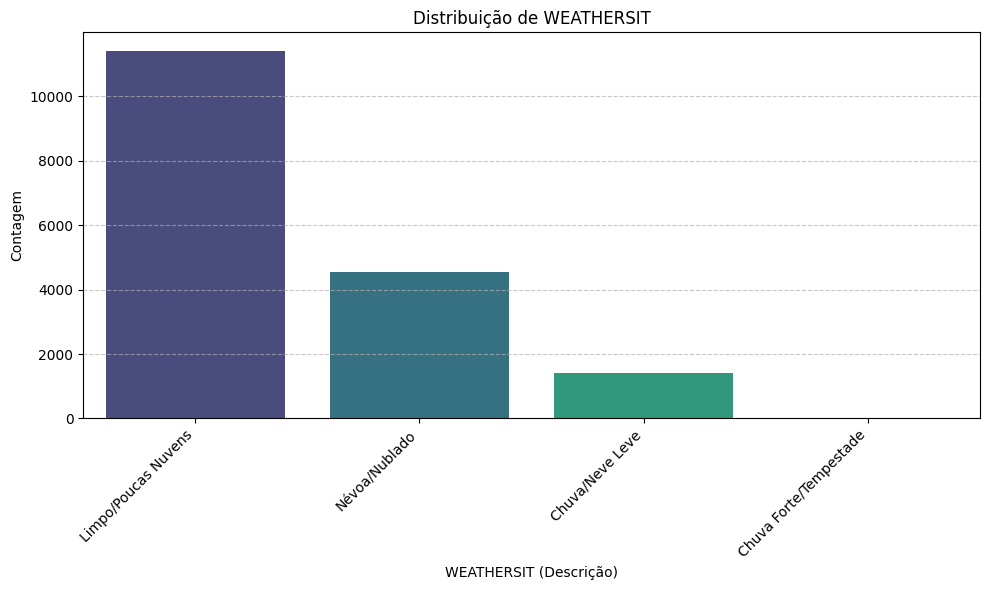

In [ ]:
# Variáveis categóricas/ordinais (incluindo as numéricas que representam categorias)
categorical_like_cols_for_plot = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit'
]

# Mapeamentos para melhor visualização
season_map_rev = {1: 'Inverno', 2: 'Primavera', 3: 'Verão', 4: 'Outono'}
yr_map = {0: '2011', 1: '2012'}
holiday_map = {0: 'Não Feriado', 1: 'Feriado'}
weekday_map = {0: 'Dom', 1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb'}
workingday_map = {0: 'Não Dia Útil', 1: 'Dia Útil'}
weathersit_map = {
    1: 'Limpo/Poucas Nuvens',
    2: 'Névoa/Nublado',
    3: 'Chuva/Neve Leve',
    4: 'Chuva Forte/Tempestade'
}

mappings = {
    'season': season_map_rev,
    'yr': yr_map,
    'holiday': holiday_map,
    'weekday': weekday_map,
    'workingday': workingday_map,
    'weathersit': weathersit_map
}

for col in categorical_like_cols_for_plot:
    plt.figure(figsize=(10, 6))

    # Conta frequência usando os valores numéricos originais (preserva ordem natural)
    value_counts = df_clean[col].value_counts().sort_index()

    # Aplica labels (se houver) na ordem já correta
    if col in mappings:
        labels = [mappings[col][v] for v in value_counts.index]
        xlabel = f'{col.upper()} (Descrição)'
    else:
        labels = list(value_counts.index)
        xlabel = col.upper()

    sns.barplot(x=labels, y=value_counts.values, palette='viridis')
    plt.title(f'Distribuição de {col.upper()}')
    plt.xlabel(xlabel)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Leitura dos gráficos de barras

Os gráficos das variáveis temporais (`season`, `yr`, `mnth`, `hr`,
`weekday`) confirmam uma **coleta de dados regular**, sem viés
sazonal — distribuições aproximadamente uniformes. Pequenas
variações (~7% em fevereiro, ~4% nas horas 3-4) correspondem aos
*gaps* identificados na Etapa 2.

`holiday` (~3%) e `workingday` (~68%) refletem proporções esperadas
do calendário.

O gráfico de **`weathersit` é o de maior valor analítico**:
mostra forte desbalanceamento (65% limpo, 26% nublado, 8% chuva
leve, <0,02% tempestade). A categoria 4 conta com apenas **3
registros** em 17.379 — base insuficiente para inferência
estatística. Análises bivariadas envolvendo `weathersit=4`
precisarão ser interpretadas com cautela ou agregadas com a
categoria 3.

As distribuições temporais documentam a estrutura da **coleta**,
mas o comportamento do **fenômeno** (aluguel de bicicletas em
função de tempo, clima, calendário) só emerge na análise bivariada
da Etapa 5.

**5. Análise Bivariada / Multivariada**
 - Verifique a existência de relação entre variáveis através da análise de correlação (dados quantitativos) e de tabelas de contingência (dados qualitativos)
 - Gere gráficos que permita a visualização da associação entre as variáveis:
    - scatterplots
    - heatmap de correlação

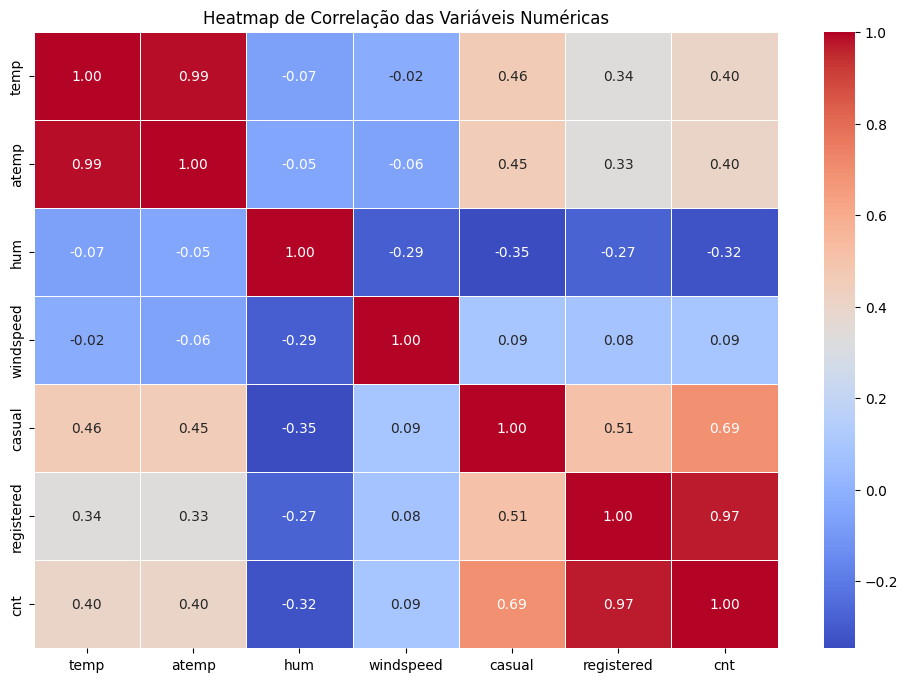

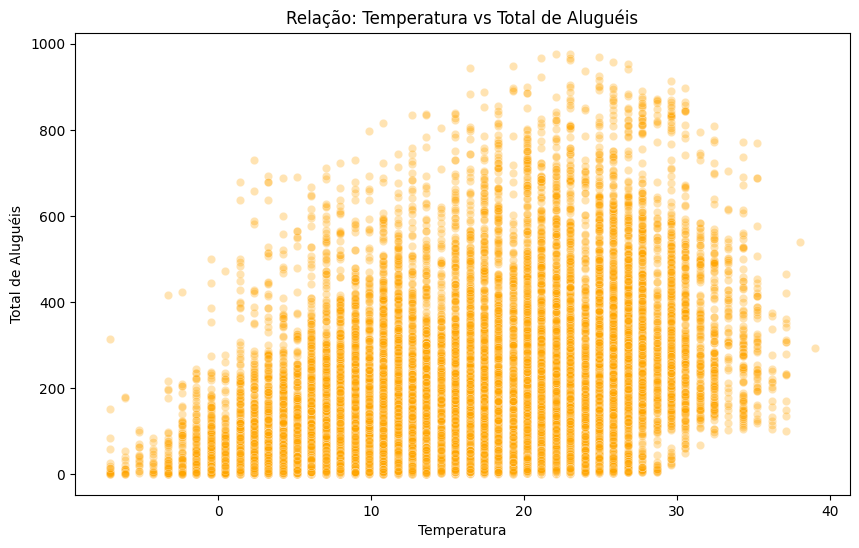

/tmp/ipykernel_10207/2788364199.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='weathersit', y='cnt', palette='Set2')


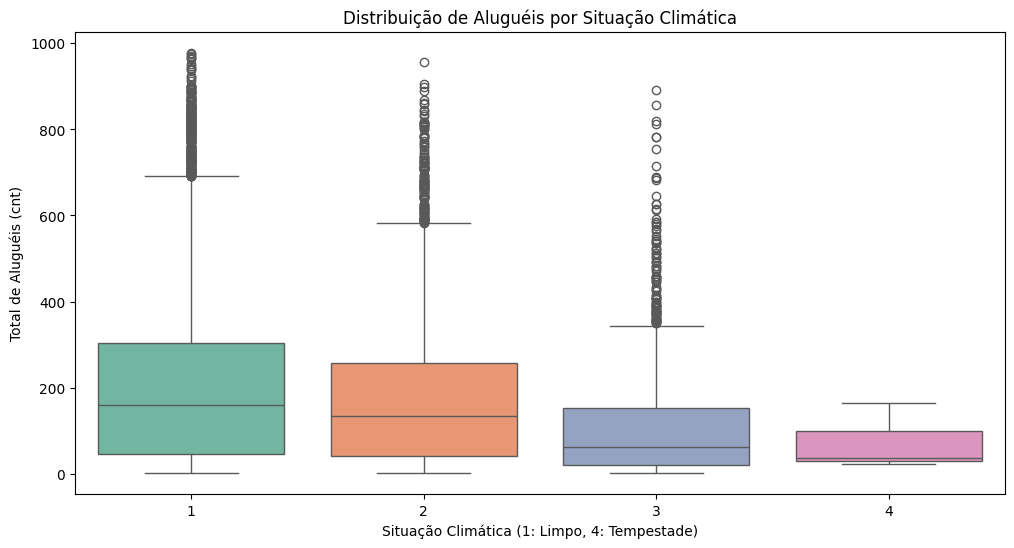

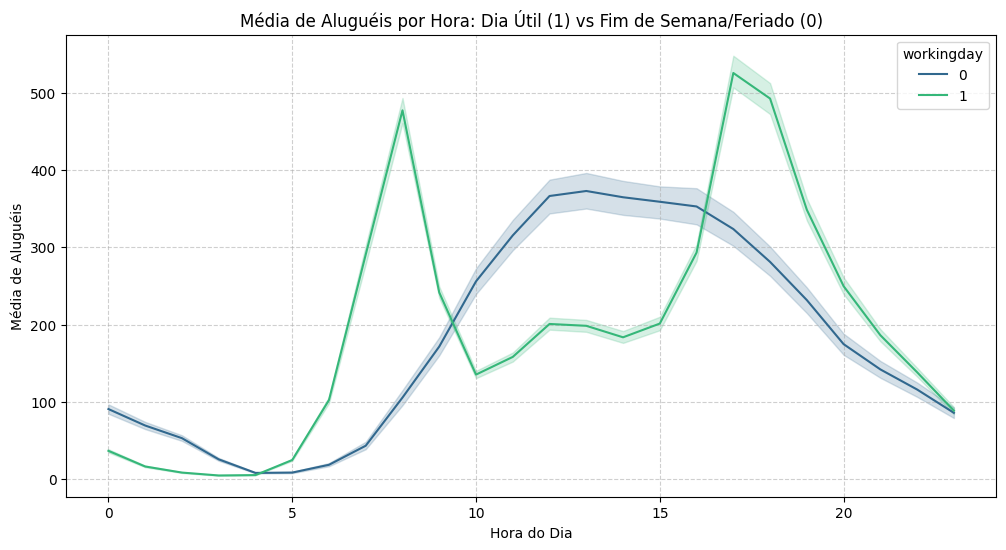

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 5. Análise Bivariada / Multivariada ---

# 5.1 Análise de Correlação (Dados Quantitativos)
# Selecionamos as variáveis numéricas contínuas e o alvo
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = df_clean[numerical_cols].corr()

# Heatmap de Correlação
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de Correlação das Variáveis Numéricas')
plt.show()

# 5.2 Gráficos de Dispersão (Scatterplots)
# Relação entre Temperatura e Total de Aluguéis (cnt)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='temp_celsius', y='cnt', alpha=0.3, color='orange')
plt.title('Relação: Temperatura vs Total de Aluguéis')
plt.xlabel('Temperatura')
plt.ylabel('Total de Aluguéis')
plt.show()

# 5.3 Análise de Variáveis Qualitativas (Tabelas de Contingência / Boxplots Cruzados)
# Vamos ver como o clima (weathersit) afeta o total de aluguéis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='weathersit', y='cnt', palette='Set2')
plt.title('Distribuição de Aluguéis por Situação Climática')
plt.xlabel('Situação Climática (1: Limpo, 4: Tempestade)')
plt.ylabel('Total de Aluguéis (cnt)')
plt.show()

# 5.4 Relação por Hora do Dia e Dia Útil
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='hr', y='cnt', hue='workingday', palette='viridis')
plt.title('Média de Aluguéis por Hora: Dia Útil (1) vs Fim de Semana/Feriado (0)')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Aluguéis')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

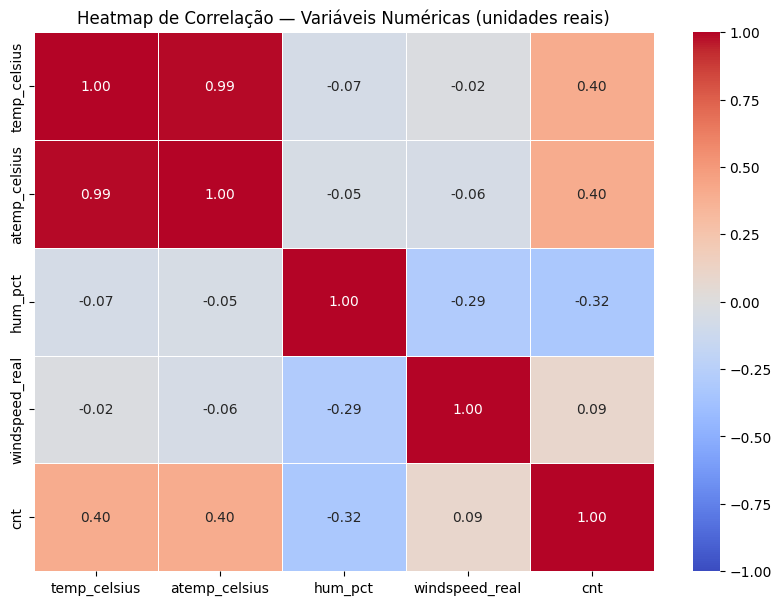

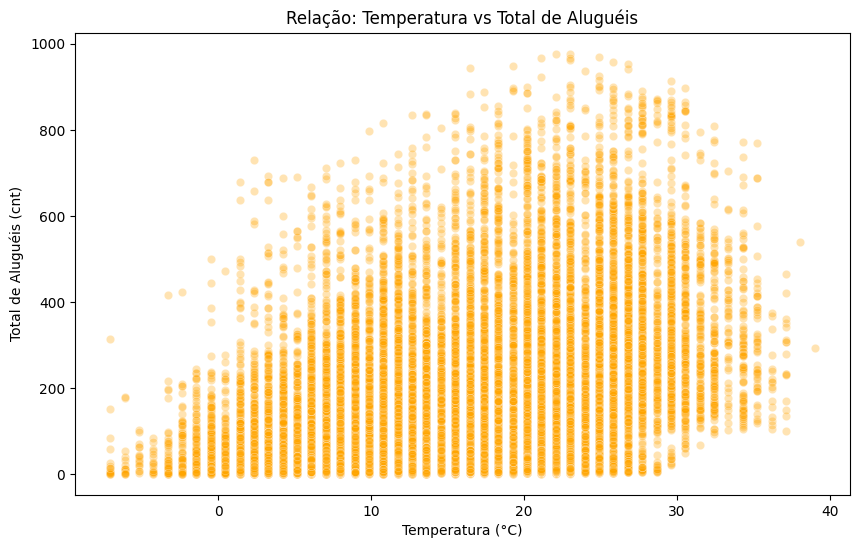

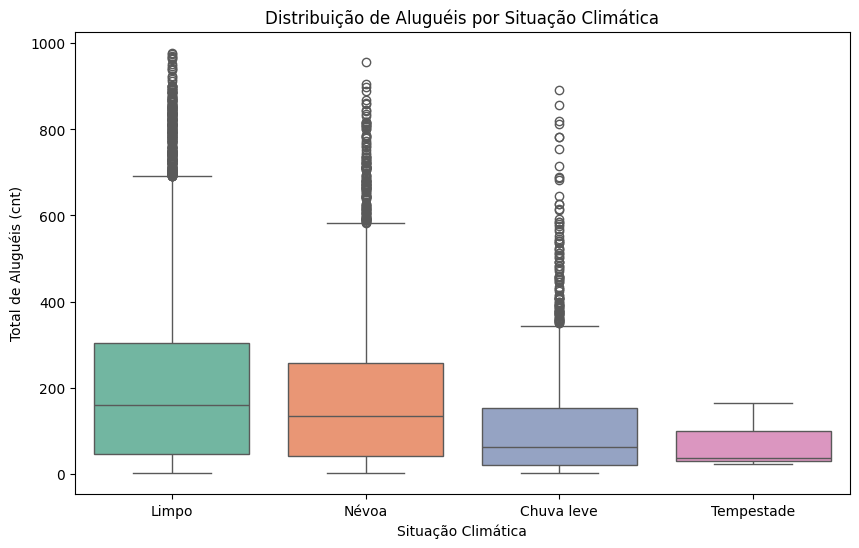

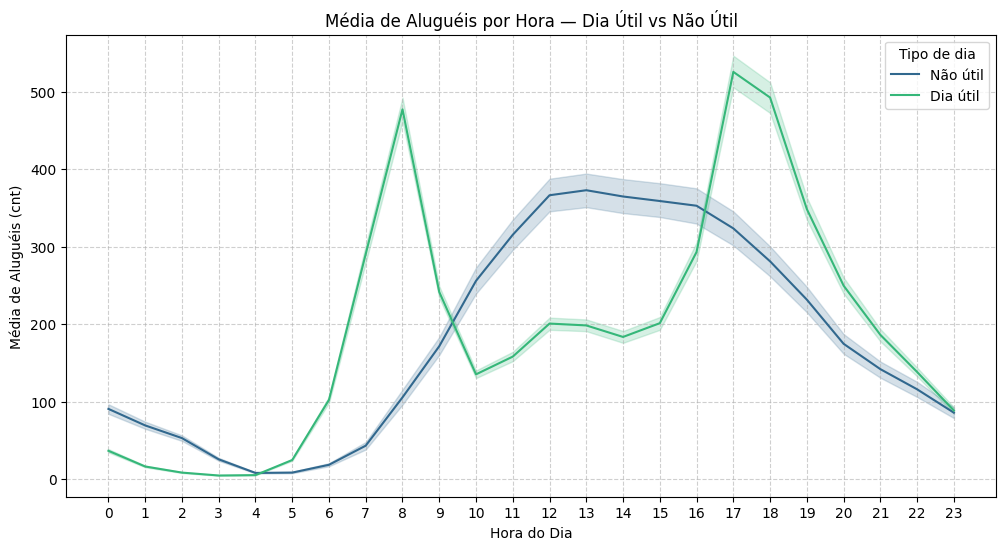

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeamentos curtos para os labels nos gráficos
weathersit_map_short = {1: 'Limpo', 2: 'Névoa', 3: 'Chuva leve', 4: 'Tempestade'}
workingday_map_short = {0: 'Não útil', 1: 'Dia útil'}

# --- 5.1 Heatmap de correlação ---
# Nota: casual e registered foram excluídas. Como cnt = casual + registered,
# sua correlação com cnt é estrutural e seria artificialmente perfeita.
numerical_cols_corr = ['temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_real', 'cnt']
corr_matrix = df_clean[numerical_cols_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Heatmap de Correlação — Variáveis Numéricas (unidades reais)')
plt.show()

# --- 5.2 Scatterplot: Temperatura vs Aluguéis ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='temp_celsius', y='cnt', alpha=0.3, color='orange')
plt.title('Relação: Temperatura vs Total de Aluguéis')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Total de Aluguéis (cnt)')
plt.show()

# --- 5.3 Boxplot: Aluguéis por situação climática (com labels legíveis) ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean.assign(
        weathersit_label=df_clean['weathersit'].map(weathersit_map_short)
    ),
    x='weathersit_label', y='cnt',
    order=['Limpo', 'Névoa', 'Chuva leve', 'Tempestade'],
    hue='weathersit_label', palette='Set2', legend=False
)
plt.title('Distribuição de Aluguéis por Situação Climática')
plt.xlabel('Situação Climática')
plt.ylabel('Total de Aluguéis (cnt)')
plt.show()

# --- 5.4 Lineplot: Aluguéis por hora, separando dia útil vs não útil ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_clean.assign(
        workingday_label=df_clean['workingday'].map(workingday_map_short)
    ),
    x='hr', y='cnt', hue='workingday_label',
    palette='viridis'
)
plt.title('Média de Aluguéis por Hora — Dia Útil vs Não Útil')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Aluguéis (cnt)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipo de dia')
plt.show()

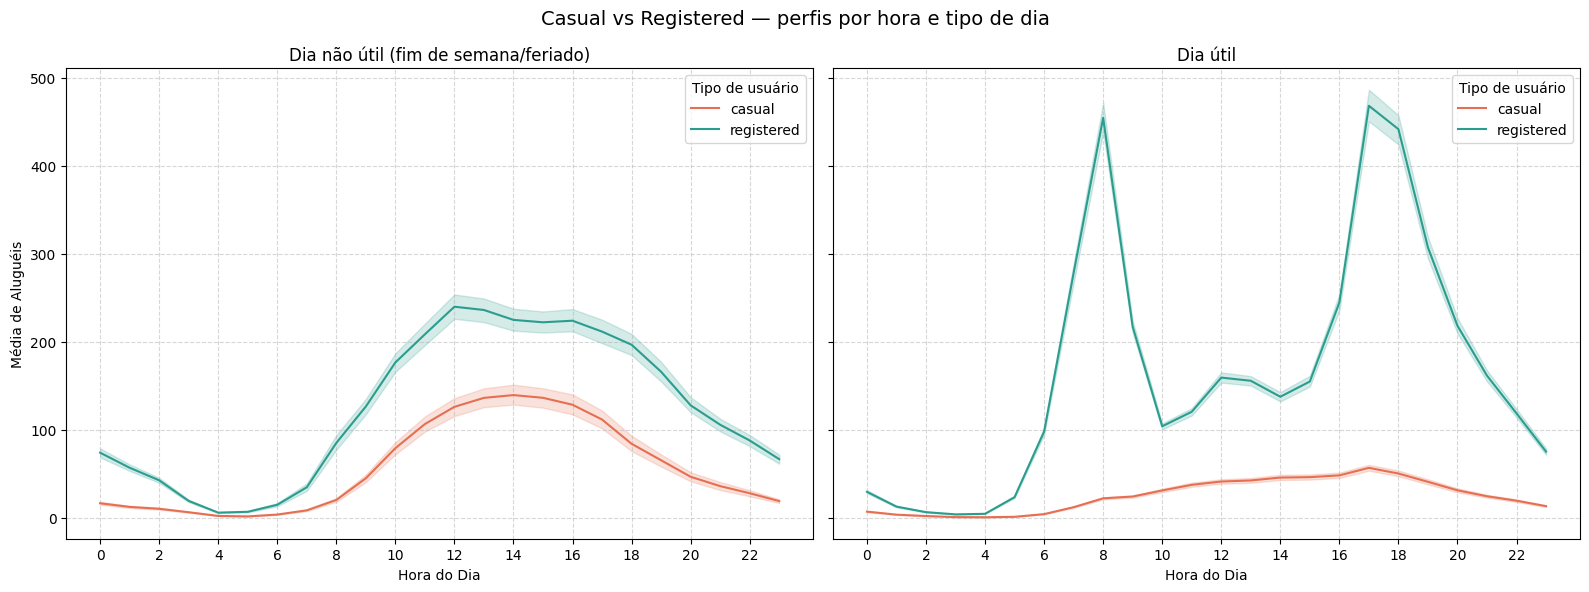

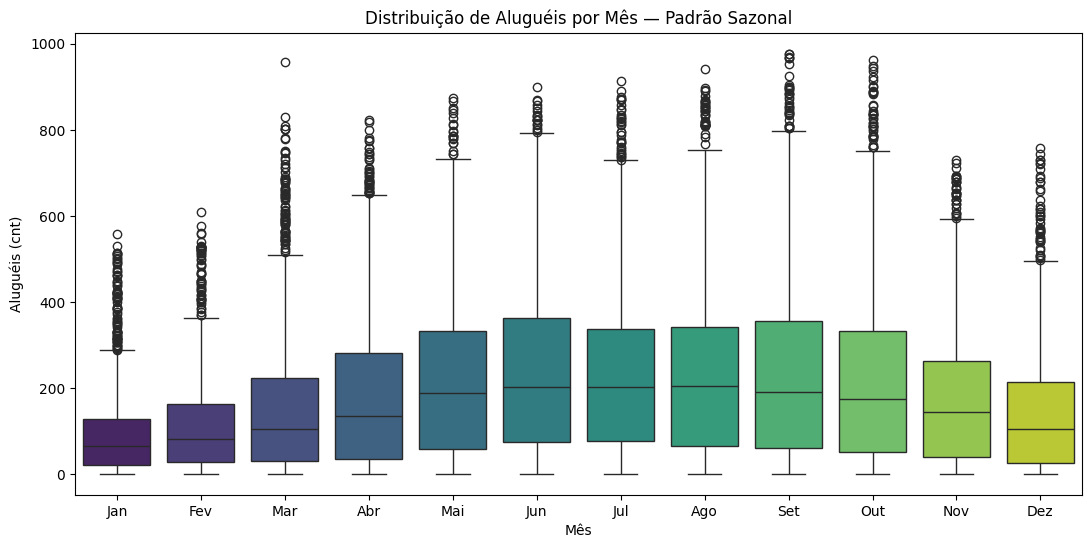

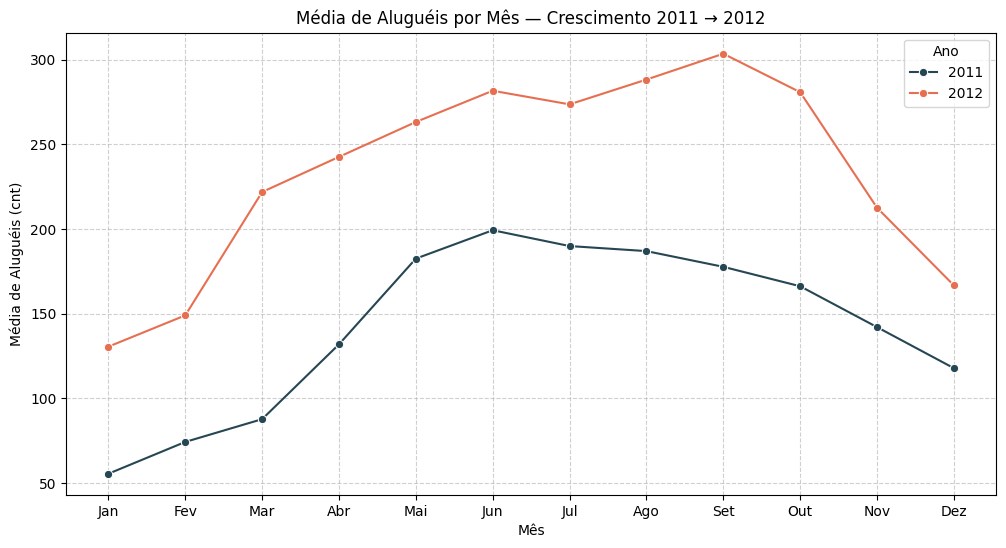

Comparativo anual:
        total  media
yr                  
2011  1243103  143.8
2012  2049576  234.7

Tabela de contingência: Estação × Situação Climática (frequência)
weathersit  Limpo  Névoa  Chuva leve  Tempestade  Total
season                                                 
Inverno      2665   1205         369           3   4242
Primavera    2859   1144         406           0   4409
Verão        3280    947         269           0   4496
Outono       2609   1248         375           0   4232
Total       11413   4544        1419           3  17379


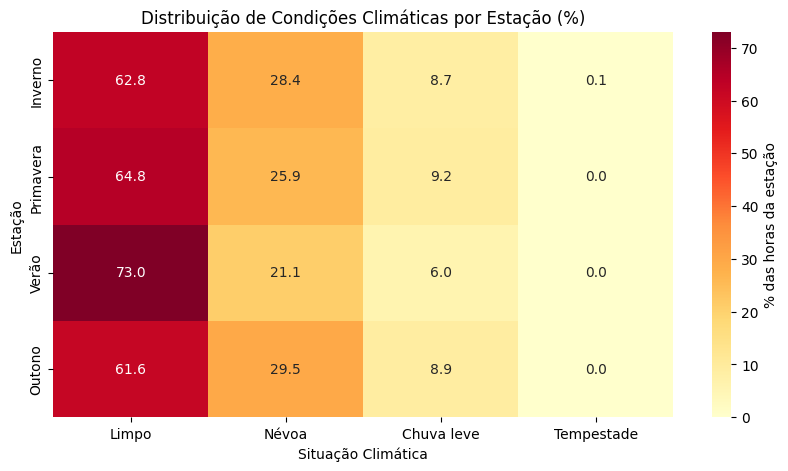

In [ ]:
# --- 5.5 Casual vs Registered por hora (separado por tipo de dia) ---
df_user_long = df_clean[['hr', 'workingday', 'casual', 'registered']].melt(
    id_vars=['hr', 'workingday'],
    var_name='Tipo de usuário', value_name='Aluguéis'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, wd_val, wd_label in [(axes[0], 0, 'Dia não útil (fim de semana/feriado)'),
                              (axes[1], 1, 'Dia útil')]:
    sns.lineplot(
        data=df_user_long[df_user_long['workingday'] == wd_val],
        x='hr', y='Aluguéis', hue='Tipo de usuário',
        palette={'casual': '#e76f51', 'registered': '#2a9d8f'},
        ax=ax
    )
    ax.set_title(wd_label)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel('Hora do Dia')
    ax.set_ylabel('Média de Aluguéis')
    ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Casual vs Registered — perfis por hora e tipo de dia', fontsize=14)
plt.tight_layout()
plt.show()


# --- 5.6 Sazonalidade: distribuição de aluguéis por mês ---
mnth_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=df_clean.assign(mnth_label=df_clean['mnth'].map(mnth_map)),
    x='mnth_label', y='cnt',
    order=list(mnth_map.values()),
    hue='mnth_label', palette='viridis', legend=False
)
plt.title('Distribuição de Aluguéis por Mês — Padrão Sazonal')
plt.xlabel('Mês')
plt.ylabel('Aluguéis (cnt)')
plt.show()


# --- 5.7 Crescimento ano a ano (2011 vs 2012) ---
monthly_avg = df_clean.groupby(['yr', 'mnth'])['cnt'].mean().reset_index()
monthly_avg['Ano'] = monthly_avg['yr'].map({0: '2011', 1: '2012'})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_avg, x='mnth', y='cnt', hue='Ano',
    marker='o', palette={'2011': '#264653', '2012': '#e76f51'}
)
plt.title('Média de Aluguéis por Mês — Crescimento 2011 → 2012')
plt.xlabel('Mês')
plt.ylabel('Média de Aluguéis (cnt)')
plt.xticks(range(1, 13), list(mnth_map.values()))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Comparativo numérico
print('Comparativo anual:')
print(
    df_clean.groupby('yr')['cnt']
    .agg(total='sum', media='mean')
    .rename(index={0: '2011', 1: '2012'})
    .round(1)
)


# --- 5.8 Tabela de contingência: Estação × Situação Climática ---
season_map_full = {1: 'Inverno', 2: 'Primavera', 3: 'Verão', 4: 'Outono'}
weathersit_map_short = {1: 'Limpo', 2: 'Névoa', 3: 'Chuva leve', 4: 'Tempestade'}

# Frequências absolutas
ct = pd.crosstab(
    df_clean['season'].map(season_map_full),
    df_clean['weathersit'].map(weathersit_map_short),
    margins=True, margins_name='Total'
)
season_order = [s for s in ['Inverno', 'Primavera', 'Verão', 'Outono', 'Total'] if s in ct.index]
weather_order = [w for w in ['Limpo', 'Névoa', 'Chuva leve', 'Tempestade', 'Total'] if w in ct.columns]
ct = ct.reindex(index=season_order, columns=weather_order, fill_value=0)

print('\nTabela de contingência: Estação × Situação Climática (frequência)')
print(ct)

# Proporções dentro de cada estação (linha = 100%)
ct_pct = pd.crosstab(
    df_clean['season'].map(season_map_full),
    df_clean['weathersit'].map(weathersit_map_short),
    normalize='index'
) * 100
ct_pct = ct_pct.reindex(
    index=[s for s in season_order if s != 'Total'],
    columns=[w for w in weather_order if w != 'Total'],
    fill_value=0
)

plt.figure(figsize=(10, 5))
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% das horas da estação'})
plt.title('Distribuição de Condições Climáticas por Estação (%)')
plt.xlabel('Situação Climática')
plt.ylabel('Estação')
plt.show()

### Leitura da análise bivariada estendida

**Casual vs Registered (5.5) — o insight central da Etapa 5:**

O sistema atende **dois fenômenos completamente diferentes**:

- Em **dias úteis**, `registered` mostra perfil bimodal típico de
  *commute* (picos ~470 às 8h e 17h). Usuários casuais ficam
  irrelevantes (~20-60).
- Em **dias não úteis**, ambos têm comportamento de lazer (sino
  largo no meio do dia), com `registered` ainda dominando em volume.

`registered` é 3-4× maior que `casual` em qualquer cenário —
representa o "core business" do sistema. A média total de `cnt`
esconde a coexistência desses dois regimes de uso.

**Sazonalidade (5.6):**

Demanda dobra entre o inverno (mediana ~70) e o pico do verão
(mediana ~200). Setembro emerge como o melhor mês — combinação
de temperatura agradável com clima ainda dentro da "temporada".
Sazonalidade é o segundo maior driver do uso, depois do horário.

**Crescimento 2011 → 2012 (5.7):**

O sistema cresceu **+65% em um ano** (1.24M → 2.05M aluguéis).
2012 fica sistematicamente acima de 2011 em todos os meses, com
mesma forma sazonal — crescimento é estrutural, não conjuntural.
**Implicação para modelagem:** a variável `yr` carrega informação
substancial e não pode ser ignorada em modelos preditivos.

**Tabela de contingência Estação × Clima (5.8):**

As **3 únicas horas com `weathersit=4` (tempestade) estão todas no
inverno**, consistente com a nor'easter de janeiro/2011 documentada
na Etapa 2. Em termos relativos, o verão é a estação mais limpa
(73% das horas), enquanto o outono concentra mais condições adversas
(30% névoa + 9% chuva). As diferenças, no entanto, são moderadas —
DC tem clima razoavelmente estável ao longo do ano.

---

### Síntese — respondendo às perguntas norteadoras da Etapa 1

| Pergunta | Resposta |
|---|---|
| Padrões temporais | ✅ Dois perfis (commute em dias úteis, lazer em não úteis); forte sazonalidade anual; crescimento de +65% em 2012 |
| Influência do clima | ✅ Temperatura tem maior efeito (não-linear, pico em ~25°C); umidade efeito moderado negativo; vento praticamente irrelevante |
| Perfis de usuário | ✅ Registered = commuters (bimodal em dias úteis); casual = lazer (unimodal); registered domina 3-4× em volume |
| Crescimento 2011→2012 | ✅ +65% em volume, mantendo padrão sazonal |

**6. Identificação de Padrões**
- Existe algum padrão claro?
- Existem outliers? Como impactam os dados?
- Alguma variável pode ser transformado?
- Alguma variável parece ser mais relevante para o potencial objetivo sugerido?

In [ ]:
df_clean.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,temp_celsius,atemp_celsius,hum_pct,windspeed_real
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,3.28,3.0014,81.0,0.0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,2.34,1.9982,80.0,0.0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,2.34,1.9982,80.0,0.0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,3.28,3.0014,75.0,0.0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,3.28,3.0014,75.0,0.0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   instant         17379 non-null  int64         
 1   dteday          17379 non-null  datetime64[ns]
 2   season          17379 non-null  int64         
 3   yr              17379 non-null  int64         
 4   mnth            17379 non-null  int64         
 5   hr              17379 non-null  int64         
 6   holiday         17379 non-null  int64         
 7   weekday         17379 non-null  int64         
 8   workingday      17379 non-null  int64         
 9   weathersit      17379 non-null  int64         
 10  temp            17379 non-null  float64       
 11  atemp           17379 non-null  float64       
 12  hum             17379 non-null  float64       
 13  windspeed       17379 non-null  float64       
 14  casual          17379 non-null  int64         
 15  re

In [ ]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357


### 6.1 Padrões claros identificados

A análise bivariada revelou cinco padrões consistentes:

1. **Padrão de commute (dias úteis):** perfil bimodal com picos
   às 8h e 17-18h, dominado quase totalmente por `registered`.
   Reflete uso do sistema para deslocamento casa-trabalho.

2. **Padrão de lazer (dias não úteis):** perfil unimodal com platô
   entre 12h e 17h. Ambos `casual` e `registered` participam,
   embora `registered` ainda domine em volume.

3. **Padrão sazonal:** demanda mais que dobra do inverno (mediana
   ~70) ao verão (mediana ~200), com pico em setembro. Padrão
   replicado nos dois anos do dataset.

4. **Padrão de crescimento:** sistema cresceu **+65%** de 2011
   para 2012 em volume total, mantendo a mesma forma sazonal —
   crescimento estrutural, não conjuntural.

5. **Padrão climático não-linear:** demanda cresce com temperatura
   até ~25°C e começa a decair acima de 30°C. Chuva (em qualquer
   intensidade) reduz fortemente o uso, enquanto névoa tem efeito
   praticamente igual ao tempo limpo.

In [ ]:
# --- 6.2 Outliers: quantificação e impacto ---
import numpy as np

# Outliers em cnt pela regra do IQR (1.5×IQR)
Q1 = df_clean['cnt'].quantile(0.25)
Q3 = df_clean['cnt'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
outliers_cnt = df_clean[df_clean['cnt'] > limite_sup]

print('--- Outliers em cnt (regra do IQR) ---')
print(f'Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}')
print(f'Limite superior (Q3 + 1.5×IQR): {limite_sup:.0f}')
print(f'Registros acima do limite: {len(outliers_cnt):,} '
      f'({len(outliers_cnt)/len(df_clean):.1%} do dataset)')

# Onde estão os outliers — por hora
print('\n--- Distribuição dos outliers por hora ---')
print(outliers_cnt['hr'].value_counts().sort_index().to_string())

# Onde estão os outliers — por workingday
print('\n--- Outliers por tipo de dia ---')
prop_outlier = outliers_cnt['workingday'].value_counts(normalize=True)
prop_geral   = df_clean['workingday'].value_counts(normalize=True)
print(f'Dia útil:    outliers {prop_outlier.get(1, 0):.1%}  |  geral {prop_geral.get(1, 0):.1%}')
print(f'Não útil:    outliers {prop_outlier.get(0, 0):.1%}  |  geral {prop_geral.get(0, 0):.1%}')

# Comparação média vs mediana — evidencia o efeito da cauda
print('\n--- Efeito da cauda nas estatísticas ---')
print(f"Média de cnt:   {df_clean['cnt'].mean():.1f}")
print(f"Mediana de cnt: {df_clean['cnt'].median():.0f}")
print(f"Razão média/mediana: {df_clean['cnt'].mean() / df_clean['cnt'].median():.2f} "
      f"(quanto maior que 1, mais cauda à direita)")

--- Outliers em cnt (regra do IQR) ---
Q1 = 40, Q3 = 281, IQR = 241
Limite superior (Q3 + 1.5×IQR): 642
Registros acima do limite: 505 (2.9% do dataset)

--- Distribuição dos outliers por hora ---
hr
8     127
11      2
12     17
13     23
14     15
15     13
16     12
17    153
18    129
19     14

--- Outliers por tipo de dia ---
Dia útil:    outliers 82.0%  |  geral 68.3%
Não útil:    outliers 18.0%  |  geral 31.7%

--- Efeito da cauda nas estatísticas ---
Média de cnt:   189.5
Mediana de cnt: 142
Razão média/mediana: 1.33 (quanto maior que 1, mais cauda à direita)


**7. Comunicação dos Resultados**
- Quais são os principais insights?
- O que foi surpreendente?
- Quais hipóteses podem ser levantadas?


## Apresentação

- Elabore uma apresentação de cerca de 15 minutos, descrevendo seu conjunto de dados, as principais informações obtidas e hipóteses a serem investigadas.
- Submeta no SIGAA o script que você utilizou para obter os resultados apresentados no trabalho.

## Avaliação

O grupo será avaliado pelos seguintes critérios (todos possuem o mesmo peso):
- Domínio das ferramentas computacionais utilizadas para a análise de dados;
- Domínio sobre o conjunto de dados;
- Apresentação do trabalho;
- Participação na discussão da apresentação dos outros grupos.


# Grupo 9

- Felipe Augusto Figueiredo Da Silva
- Francisco José Da Silva Mendes
- Lucas Gabriel Castro Medeiros Da Silva

Dataset: https://www.google.com/url?q=https%3A%2F%2Farchive.ics.uci.edu%2Fdataset%2F275%2Fbike%2Bsharing%2Bdataset

# Sobre o Dataset

- **Nome:** Bike Sharing
- **Descrição:** "*This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.*"

- **Área de estudo:** Ciências Sociais
- **Tarefas associadas:** Regressão Linear
- **Número de instâncias (records/instances):** 17379
- **Número de características (features):** 13
- **Valores Faltantes (Missing Values):** 0
- **Informações Adicionais:** "Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data."

# Tabela de Variáveis

| Variable Name | Role    | Type        | Description                                                                                                                                 | Units | Missing Values |
|---------------|---------|-------------|---------------------------------------------------------------------------------------------------------------------------------------------|-------|----------------|
| instant       | ID      | Integer     | record index                                                                                                                                |       | no             |
| dteday        | Feature | Date        | date                                                                                                                                        |       | no             |
| season        | Feature | Categorical | 1:winter, 2:spring, 3:summer, 4:fall                                                                                                        |       | no             |
| yr            | Feature | Categorical | year (0: 2011, 1: 2012)                                                                                                                     |       | no             |
| mnth          | Feature | Categorical | month (1 to 12)                                                                                                                             |       | no             |
| hr            | Feature | Categorical | hour (0 to 23)                                                                                                                              |       | no             |
| holiday       | Feature | Binary      | weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)                                                     |       | no             |
| weekday       | Feature | Categorical | day of the week                                                                                                                             |       | no             |
| workingday    | Feature | Binary      | f day is neither weekend nor holiday is 1, otherwise is 0                                                                                   |       | no             |
| weathersit    | Feature | Categorical | - 1: Clear, Few clouds, Partly cloudy, Partly cloudy                                                                                        |       | no             |
| temp          | Feature | Continuous  | Normalized temperature in Celsius. The values are derived via  (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)          | C     | no             |
| atemp         | Feature | Continuous  | Normalized feeling temperature in Celsius. The values are derived via  (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale) | C     | no             |
| hum           | Feature | Continuous  | Normalized humidity. The values are divided to 100 (max)                                                                                    |       | no             |
| windspeed     | Feature | Continuous  | Normalized wind speed. The values are divided to 67 (max)                                                                                   |       | no             |
| casual        | Other   | Integer     | count of casual users                                                                                                                       |       | no             |
| registered    | Other   | Integer     | count of registered users                                                                                                                   |       | no             |
| cnt           | Target  | Integer     | count of total rental bikes including both casual and registered                                                                            |       | no             |

# Informações adicionais sobre variáveis

Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv


	- instant: record index
	- dteday : date
	- season : season (1:winter, 2:spring, 3:summer, 4:fall)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit :
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
	- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
	- hum: Normalized humidity. The values are divided to 100 (max)
	- windspeed: Normalized wind speed. The values are divided to 67 (max)
	- casual: count of casual users
	- registered: count of registered users
	- cnt: count of total rental bikes including both casual and registered

# Como Utilizar:

1. Importar no Python:

```python
pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
  
# fetch dataset
bike_sharing = fetch_ucirepo(id=275)
  
# data (as pandas dataframes)
X = bike_sharing.data.features
y = bike_sharing.data.targets
  
# metadata
print(bike_sharing.metadata)
  
# variable information
print(bike_sharing.variables)

```
1.1 Documentação: https://github.com/uci-ml-repo/ucimlrepo

2. Baixar
    - 2.1 https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

3. Citação
- IEEE: H. Fanaee-T. "Bike Sharing," UCI Machine Learning Repository, 2013. [Online]. Available: https://doi.org/10.24432/C5W894.

- MLA: Fanaee-T, Hadi. "Bike Sharing." UCI Machine Learning Repository, 2013, https://doi.org/10.24432/C5W894.

- ABNT: H. Fanaee-T, 2013-12-19, “Bike Sharing”, UCI Machine Learning Repository. Consult. 2026-04-30. [Em linha]. Disponível: https://doi.org/10.24432/C5W894